# Results for Terschelling
- Difference statistics compared to JARKUS: Does it improve compared to the initial state?
- Volume changes
- Elevation changes for a few selected points
- Animation gif

## Paths & Co

In [1]:
new_initial_state = False
new_kalman_run = False
animation = False

In [2]:
# paths local laptop
datapath_jarkus = '/media/bene/Seagate/PhD-data/4_land_elevation/2_JARKUS/'
datapath_tc = '/media/bene/Seagate/PhD-data/3_ocean_tide_models/'

path_input_general = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/0_input_general/'
path_input = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/12_and_13_Ters_DEM/input/'
path_output = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/12_and_13_Ters_DEM/output/'
path_altimetry_output = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/11_Ters_altimetry/output/'

In [3]:
# other settings
# epsg = 28992 # Amersfoort
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included

# Suppress warning about mean of empty slice
# but might suppress other warnings as well
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [4]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# from cmcrameri import cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_matrix_tools, CD_visualisation

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [6]:
# Observational noise
beach_slope = 0.015 # tan beta
rmse_h_cassie = 20 # [m]
std_alt = 0.1 # [m]
rms_eot20 = 0.1  # [m]
sigma_l = np.sqrt((beach_slope * rmse_h_cassie)**2 + std_alt**2 + rms_eot20**2)

print(f'Observational noise: {round(sigma_l,2)} m')

# Model noise
factor = 10 # 10 if good trend difference important. 1 if good RMSE and correlation important.
sigma_q = factor * sigma_l
print(f'Model noise: {round(sigma_q,2)} m')

# Standard deviation of the initial state
std_init = 1
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.33 m
Model noise: 3.32 m
Standard deviation of the initial state: 1 m


In [7]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Observations

In [8]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [9]:
# Tidal correction
fn = 'tidal_correction_10minutes.csv'
tidal_corr = pd.read_csv(path_input+fn, index_col='date', parse_dates=['date'])

In [10]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


### Initial state

In [11]:
# %%prun -s cumulative
buffer_size = 500 # [m], buffer radius of target area around the median shoreline
resolution = 100 # [m], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_{resolution}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:    
    CD_kalman.initial_state(epsg, buffer_size, resolution, c_shorelines, alt, path_input+'2_global_DEMs/', path_output, fn_init)

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [12]:
init = xr.open_dataset(path_output+fn_init).squeeze()

# fn_poly_sl = f'poly_sl_{epsg}.pkl'
# poly_sl = pickle.load(open(path_output + fn_poly_sl, 'rb'))

fn_target_poly = f'poly_buffered_{epsg}.pkl'
poly_target = pickle.load(open(path_output + fn_target_poly, 'rb'))    

### Shoreline outlier rejection
(apart from observations, because requires initial state, and initial state computation requires shorelines, but not necessarily outlier-corrected)

In [13]:
# shoreline outlier rejection
init_df = init.to_dataframe().reset_index().dropna()
zcontour = CD_geometry.get_DEM_contour(init_df['x'], init_df['y'], init_df['band_data'], h=0, tarea=poly_target)

t_factor = .8 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, zcontour, epsg, t_factor)

28.999999999999996% of shoreline points were discarded.


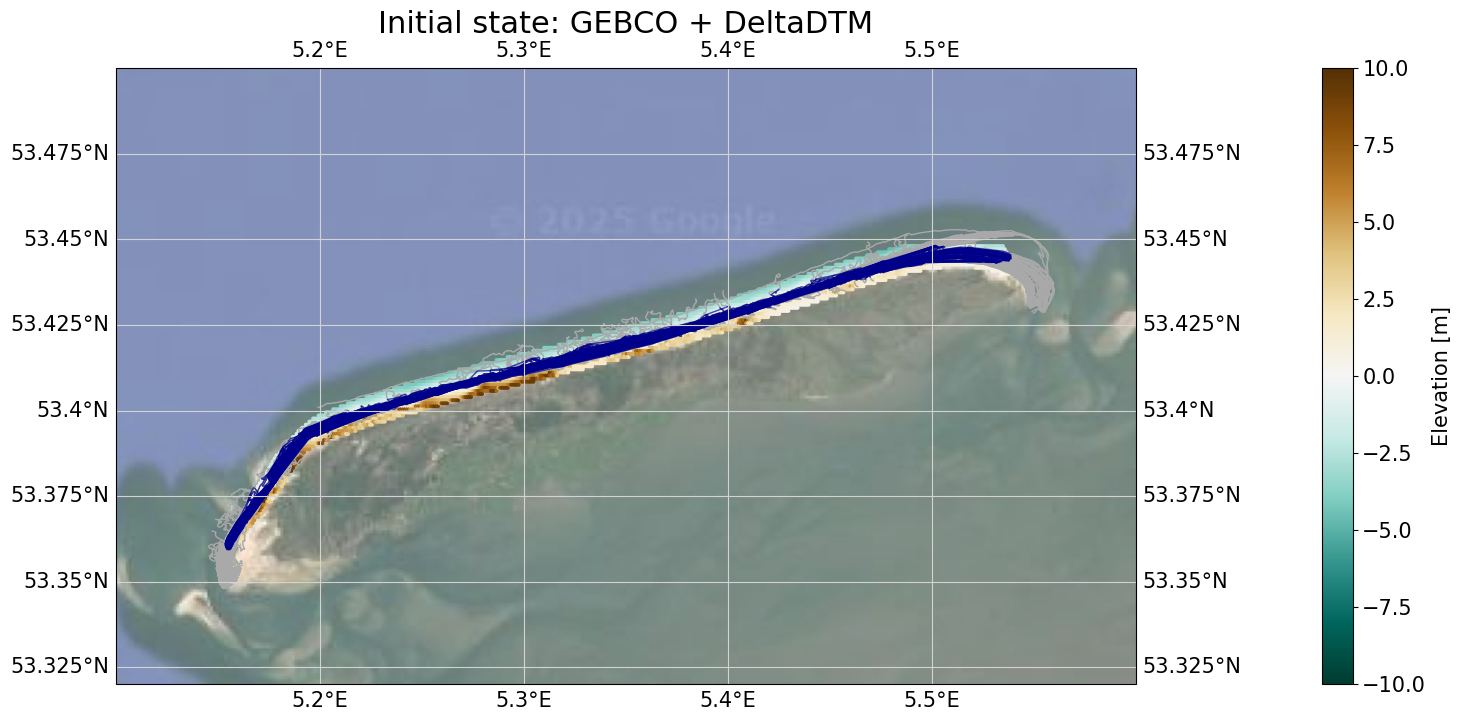

In [14]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')    
x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))

# %matplotlib qt5
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, c=x_state.init, transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-10, vmax=10)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=22);

from shapely import LineString
for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=1)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=.7)

# plt.savefig(f'{path_output}initial_state.png', dpi=300, bbox_inches='tight')

### Jarkus data

In [15]:
jarkus = xr.open_dataset(path_input_general + 'transect_red_with_derivatives.nc') #(only required to generate coastline section areas for volume changes)
jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_input_general, year_start, year_end, poly_target, init)

### Coastline section polygons

In [16]:
poly_all, poly_west, poly_center, poly_east = CD_jarkus_tools.get_Ters_section_polygons(poly_target, jarkus, buffer_vol=-250)

Reduced target polygon by 50.4 %


## Generate RTS-DTM

In [17]:
# %%prun -s cumulative
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                          epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                          sigma_l, sigma_q, eps_factor)                                                            
            
    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)
    
    
    kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state, x_state_s, updated_points)

    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

/home/bene/PhD-git/3_coastal-sea-level/coastal_data/CD_combine_data.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_gdf = pd.concat([combined_gdf, gdf_temp])


Forward run done. Needed  18.6 seconds.
Backward run done. Needed  140.6 seconds.
Interpolation done. Needed  37.6 seconds.


## Statistics of elevation differences

### Initial state - Jarkus

In [18]:
jarkus_gdf = jarkus_gdf.drop(columns=['2001', '2002', '2003'])
kf_interp = kf_interp.drop(columns=['2001', '2003'])
rts_interp = rts_interp.drop(columns=['2001', '2003'])

In [19]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(jarkus_gdf.geometry.x, jarkus_gdf.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', jarkus_gdf.geometry.x, jarkus_gdf.geometry.y)

jarkus_temp_mean = jarkus_gdf.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - jarkus_temp_mean
print(f'Difference initial state - jarkus has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - jarkus has 2917 non-NaN values.


In [20]:
CD_statistics.print_stats(diff_init)

Mean error: -0.14 m
---De-bias with mean---
Mean error: -0.0 m
Mean absolute error: 1.58 m
Root mean square error: 2.64 m
Mean absolute deviation from mean: 1.58 m
Median absolute deviation from median: 0.92 m


In [21]:
year_list = [int(_) for _ in jarkus_gdf.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], jarkus_gdf, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - Jarkus

In [22]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, jarkus_gdf, year_list, reduce_mean=True, static=False)

In [23]:
year_list = [int(_) for _ in kf_interp.drop(columns='geometry').columns]
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, jarkus_gdf, year_list, reduce_mean=True, static=False)

In [24]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

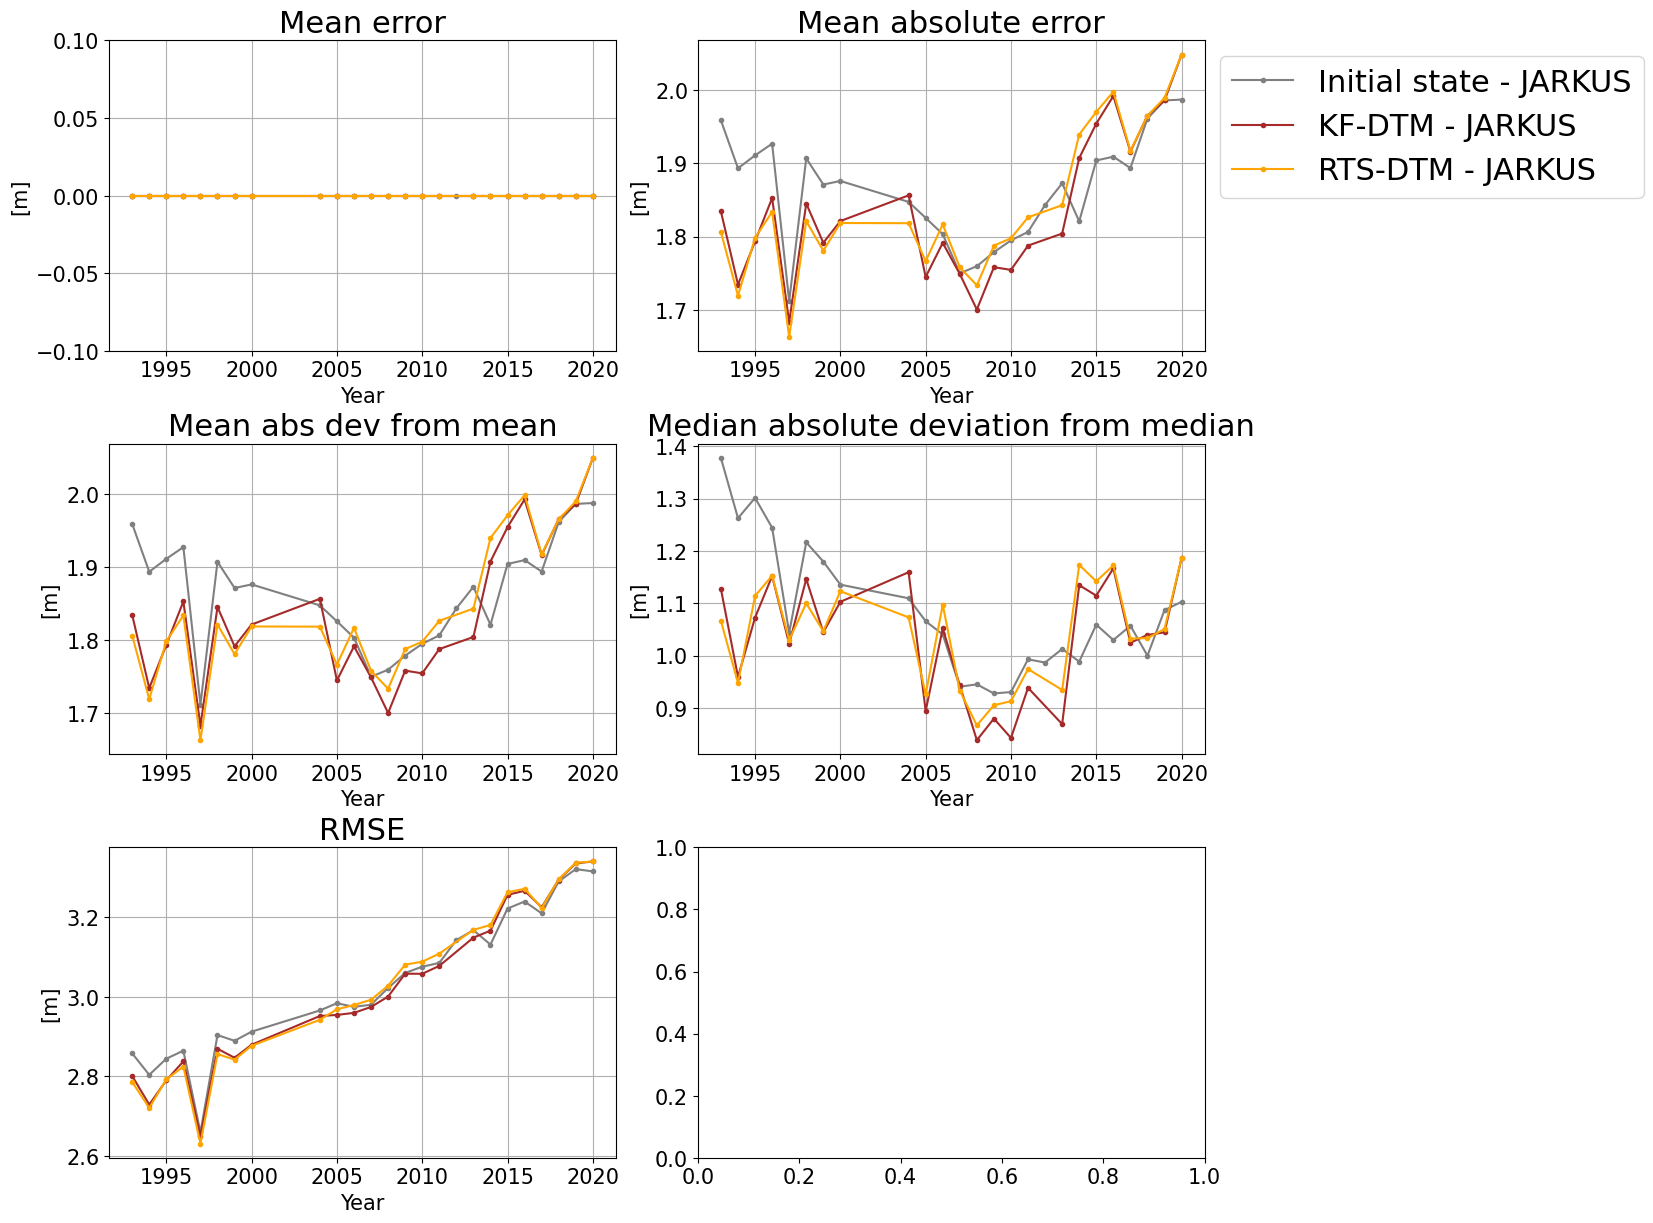

In [25]:
def plot_stats(ax, which_stat, title, legend=False):
    ax.plot(stats_gdf_init.index, stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - JARKUS')
    ax.plot(stats_gdf_kf.index, stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - JARKUS')
    ax.plot(stats_gdf_rts.index, stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - JARKUS')
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=22)
    ax.ticklabel_format(useOffset=False, style='plain')

fig, axs = plt.subplots(3, 2, figsize=(12,12))
fig.tight_layout()
fig.subplots_adjust(hspace=.3)

plot_stats(axs[0,0], which_stat='me', title='Mean error')
axs[0,0].set_ylim([-0.1, 0.1])

plot_stats(axs[0,1], which_stat='mae', title='Mean absolute error', legend=True)
plot_stats(axs[1,0], which_stat='mad_mean', title='Mean abs dev from mean')
plot_stats(axs[1,1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2,0], which_stat='rmse', title='RMSE')

plt.savefig(f'{path_output}validation_elev_difference_stats.png', dpi=300, bbox_inches='tight')

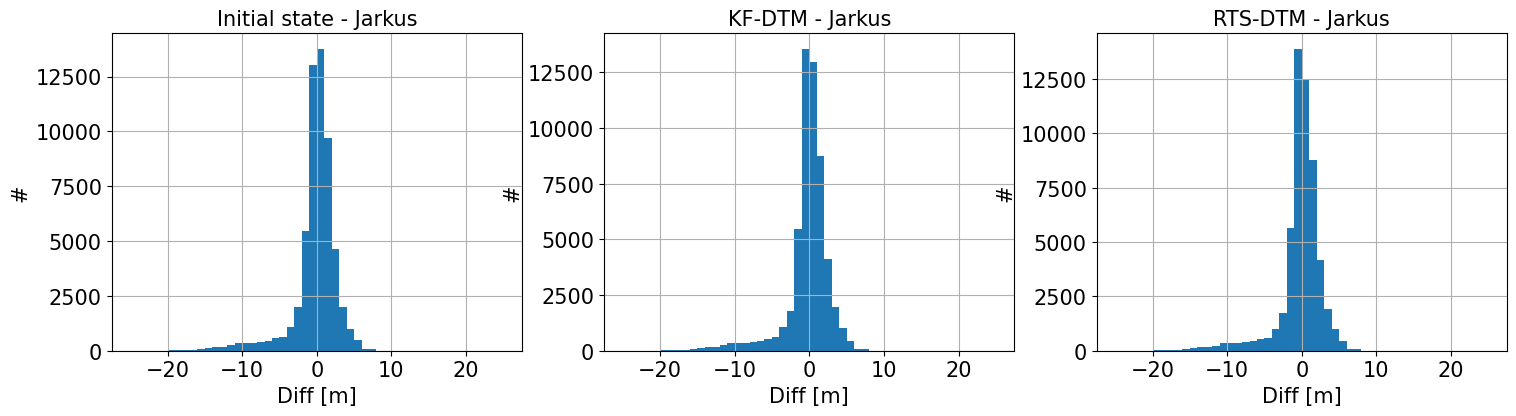

In [26]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.tight_layout()
CD_visualisation.plot_histogram(axs[0], all_diffs_init, 'Initial state - Jarkus')
CD_visualisation.plot_histogram(axs[1], all_diffs_kf, 'KF-DTM - Jarkus')
CD_visualisation.plot_histogram(axs[2], all_diffs_rts, 'RTS-DTM - Jarkus')

### Maps

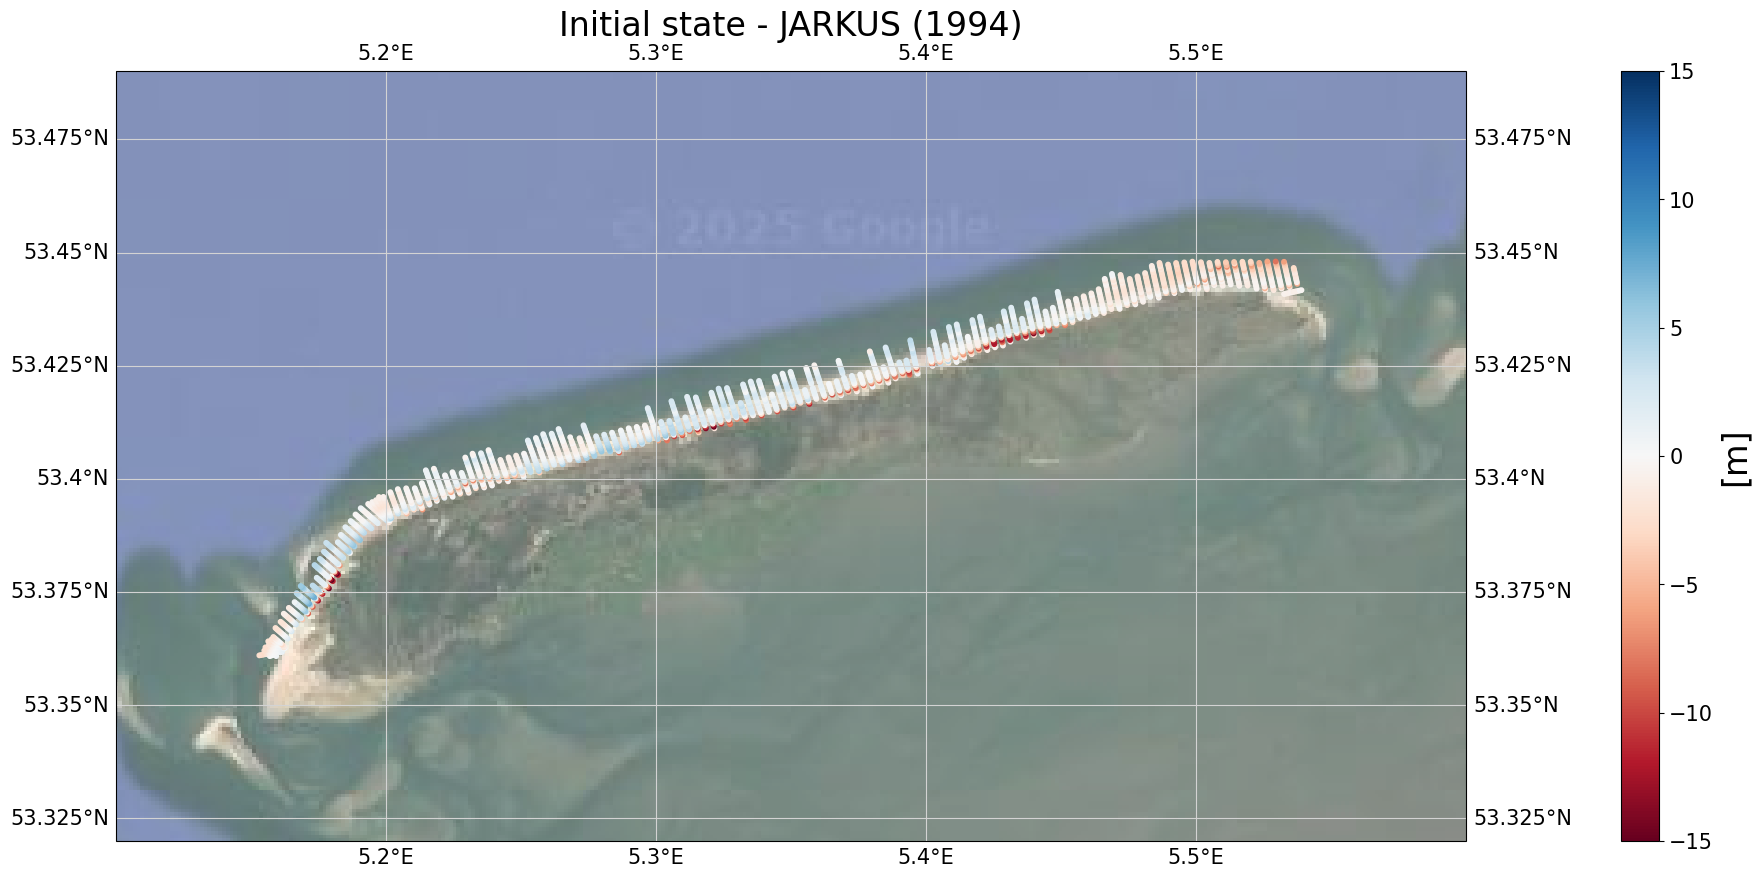

In [27]:
diff = init_interp['init'] - jarkus_gdf['1994']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = init_interp.geometry.x
y = init_interp.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-15, vmax=15)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Initial state - JARKUS (1994)', fontsize=24);

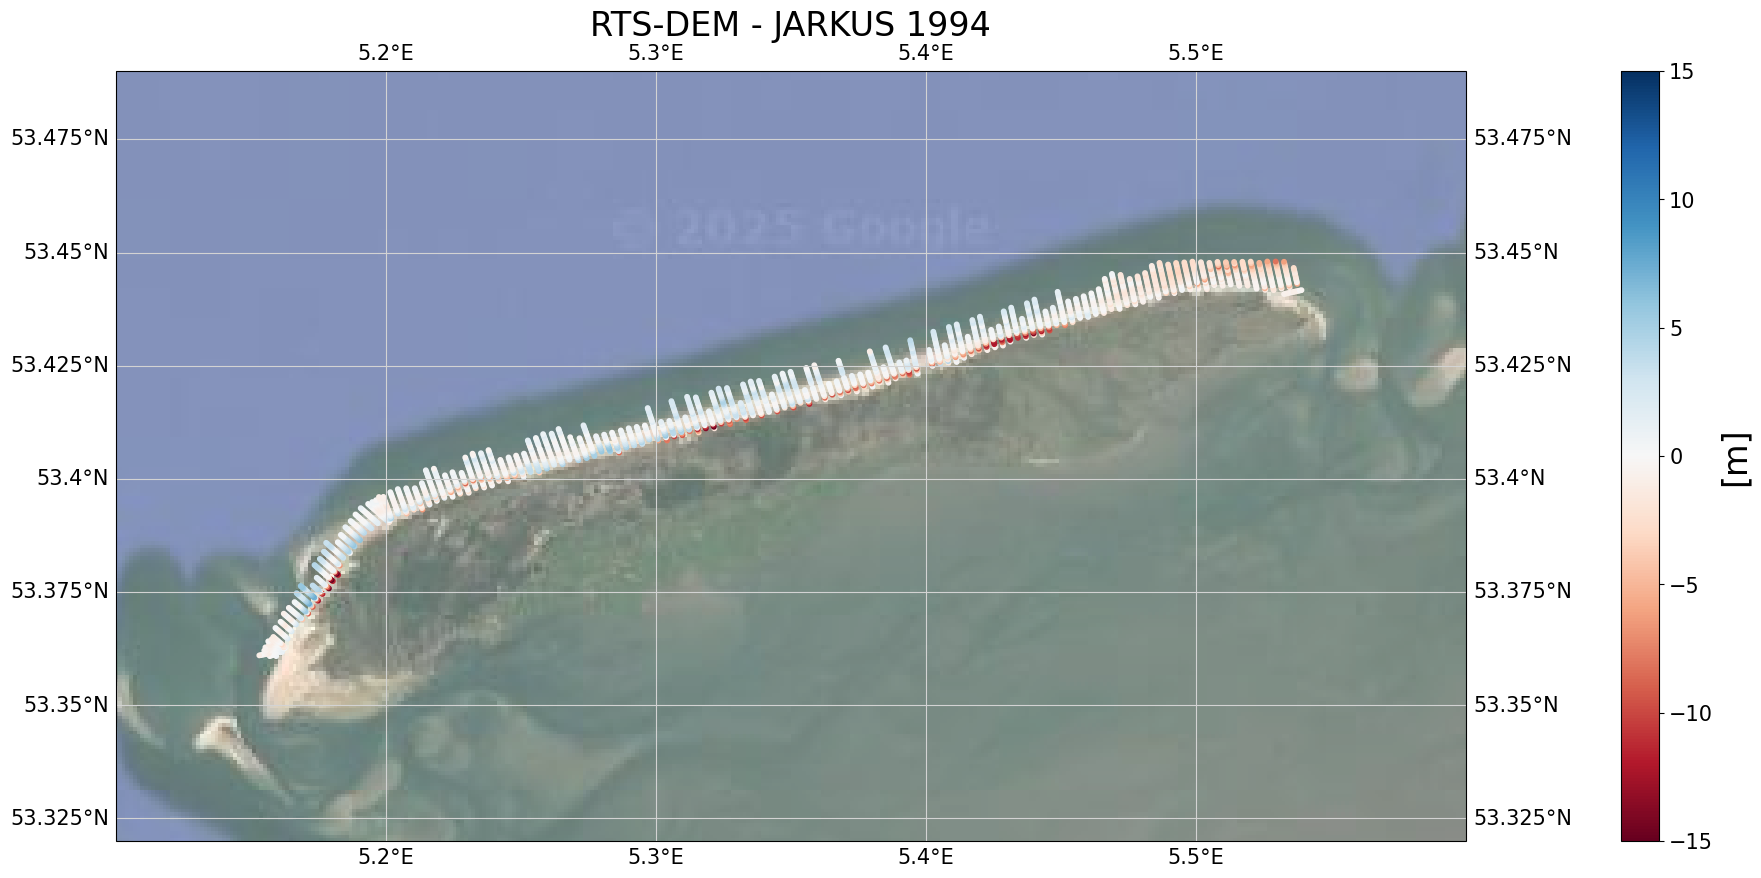

In [28]:
diff = rts_interp['1994'] - jarkus_gdf['1994']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = jarkus_gdf.geometry.x
y = jarkus_gdf.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-15, vmax=15)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('RTS-DEM - JARKUS 1994', fontsize=24);

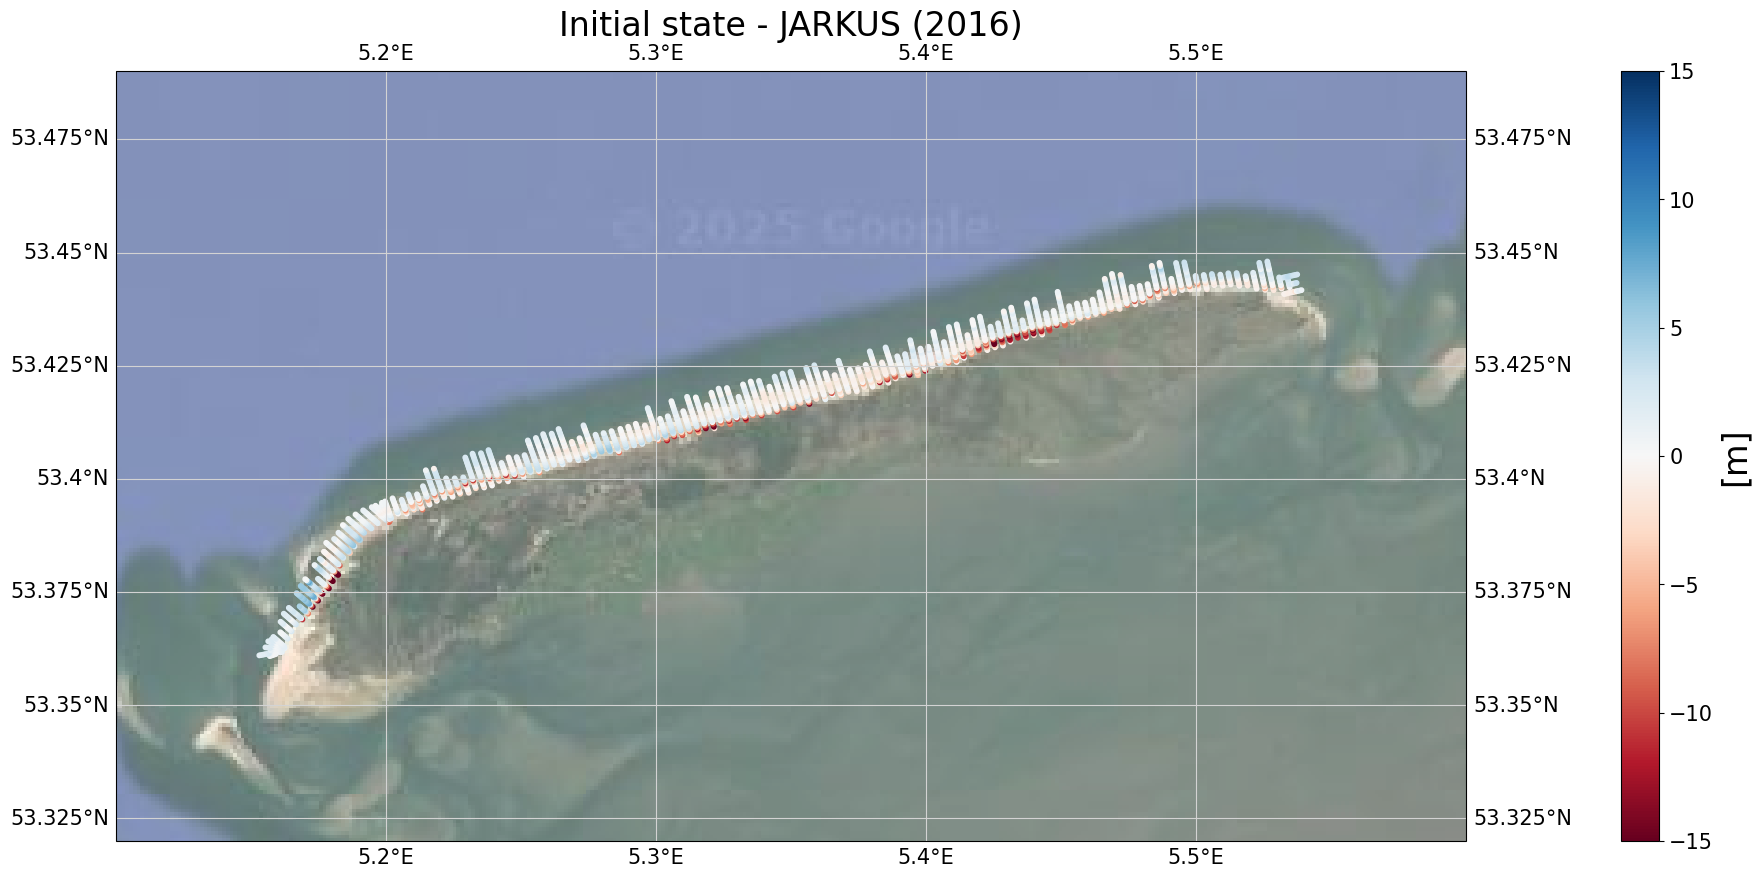

In [29]:
diff = init_interp['init'] - jarkus_gdf['2016']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = init_interp.geometry.x
y = init_interp.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-15, vmax=15)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Initial state - JARKUS (2016)', fontsize=24);

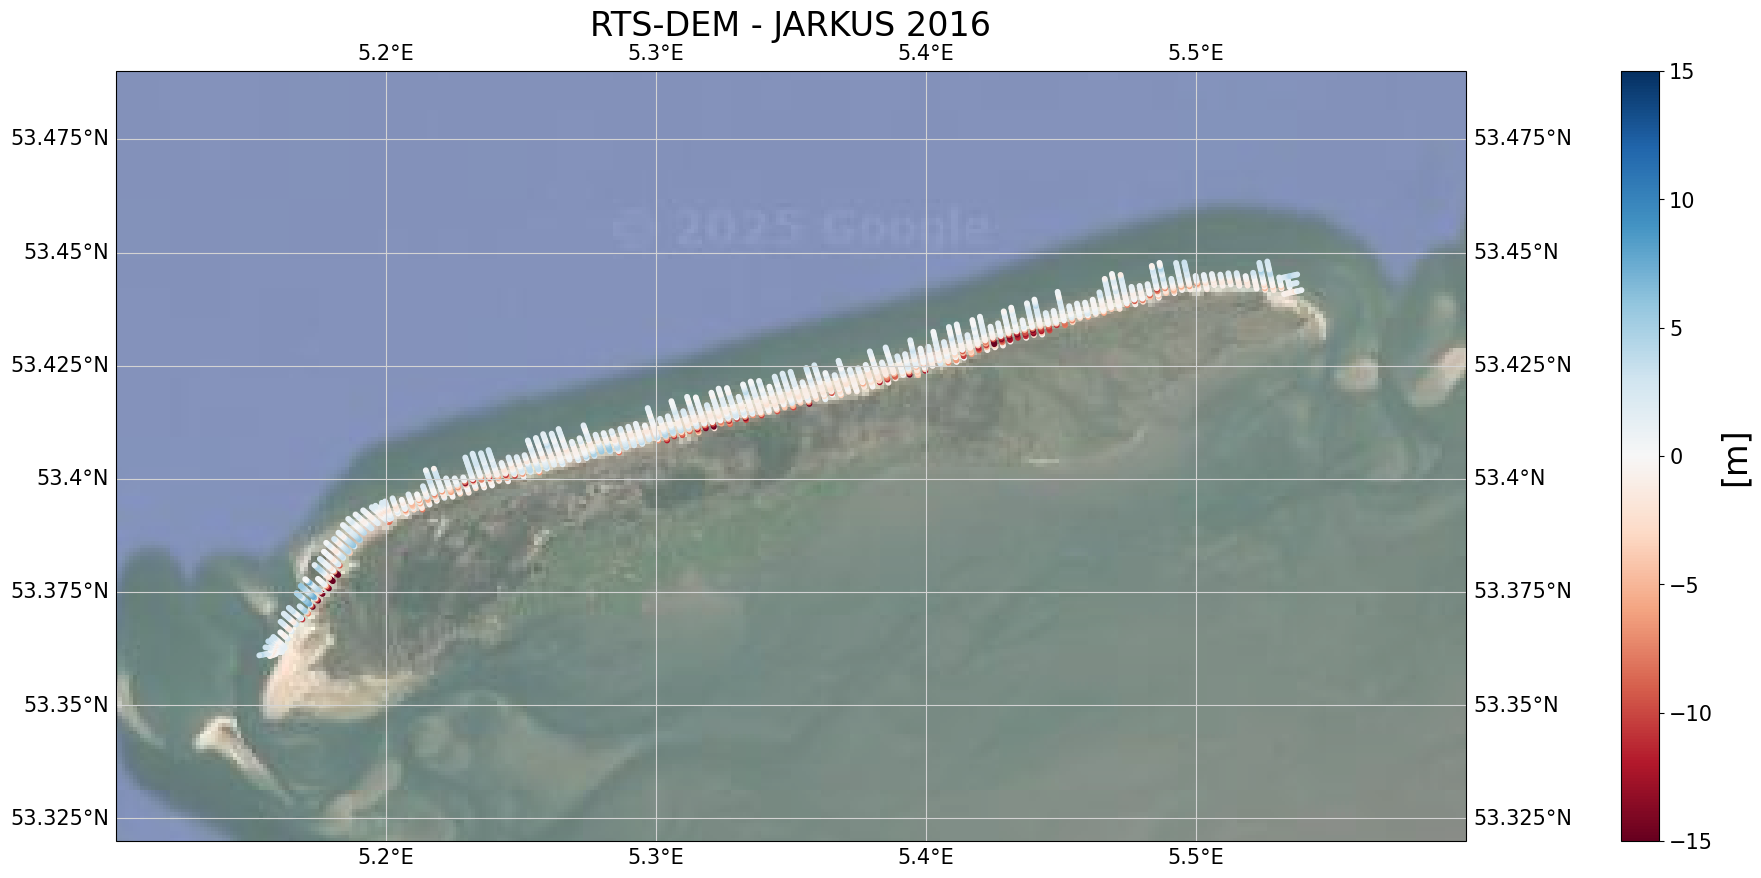

In [30]:
diff = rts_interp['2016'] - jarkus_gdf['2016']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = jarkus_gdf.geometry.x
y = jarkus_gdf.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-15, vmax=15)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('RTS-DEM - JARKUS 2016', fontsize=24);

## Time series of volume changes

In [31]:
volumes = pd.DataFrame(index=[int(_) for _ in kf_interp.drop(columns='geometry').columns])

volumes['jarkus_all'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_all, col_name='', epsg_out=28992)
volumes['kf_all'] = CD_geometry.compute_volume_changes(x_state.drop(x_state.filter(regex='^x_pred_').columns, axis=1).drop(columns='init'),
                                            poly_all, col_name= 'x_up_', epsg_out=28992)
volumes['rts_all'] = CD_geometry.compute_volume_changes(x_state_s, poly_all, col_name= 'x_s_', epsg_out=28992)

volumes['jarkus_west'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_west, col_name='', epsg_out=28992)
volumes['kf_west'] = CD_geometry.compute_volume_changes(x_state.drop(x_state.filter(regex='^x_pred_').columns, axis=1).drop(columns='init'),
                                            poly_west, col_name= 'x_up_', epsg_out=28992)
volumes['rts_west'] = CD_geometry.compute_volume_changes(x_state_s, poly_west, col_name= 'x_s_', epsg_out=28992)

volumes['jarkus_center'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_center, col_name='', epsg_out=28992)
volumes['kf_center'] = CD_geometry.compute_volume_changes(x_state.drop(x_state.filter(regex='^x_pred_').columns, axis=1).drop(columns='init'),
                                            poly_center, col_name= 'x_up_', epsg_out=28992)
volumes['rts_center'] = CD_geometry.compute_volume_changes(x_state_s, poly_center, col_name= 'x_s_', epsg_out=28992)

volumes['jarkus_east'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_east, col_name='', epsg_out=28992)
volumes['kf_east'] = CD_geometry.compute_volume_changes(x_state.drop(x_state.filter(regex='^x_pred_').columns, axis=1).drop(columns='init'),
                                            poly_east, col_name= 'x_up_', epsg_out=28992)
volumes['rts_east'] = CD_geometry.compute_volume_changes(x_state_s, poly_east, col_name= 'x_s_', epsg_out=28992)

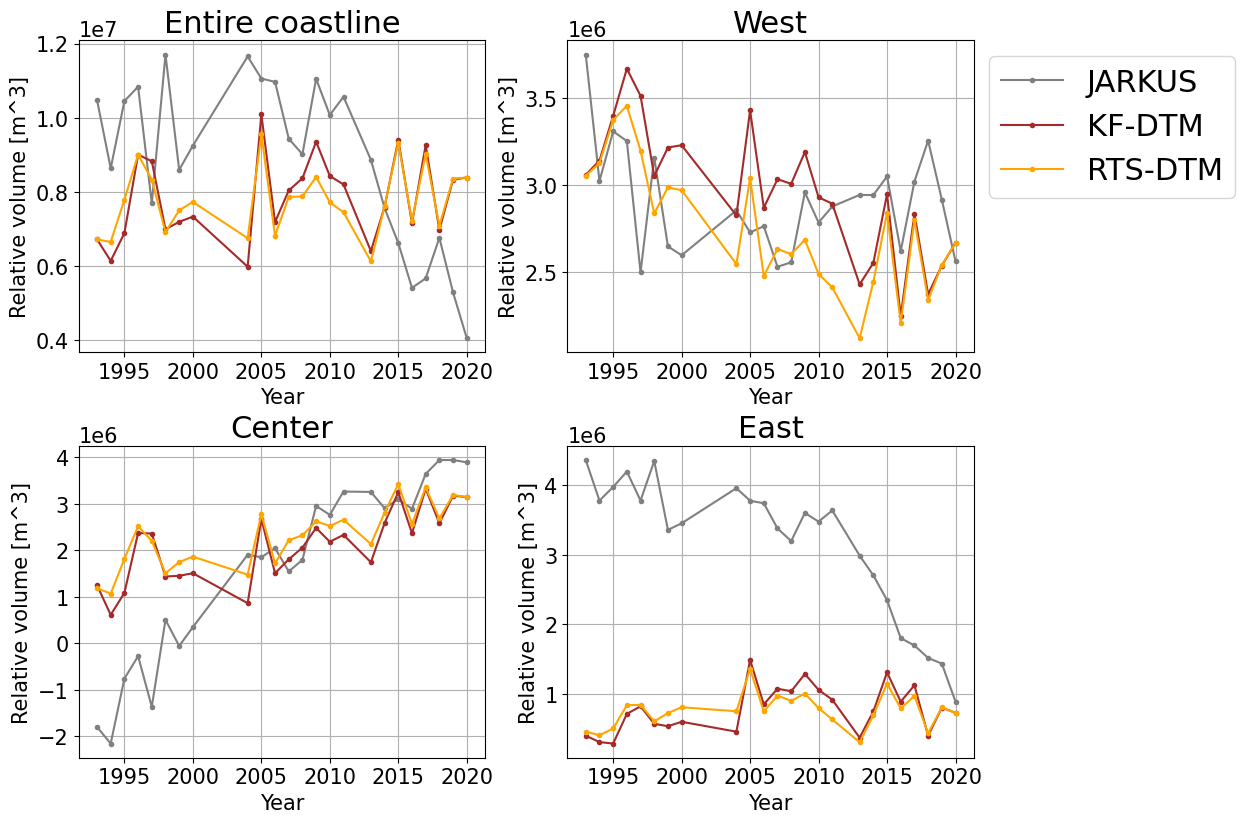

In [32]:
def plot_volume_changes(ax, vol_jarkus, vol_kf, vol_rts, title_area, legend=False):
    ax.plot(vol_jarkus.index, vol_jarkus, '.-', c=c_init, label='JARKUS')
    ax.plot(vol_kf.index, vol_kf, '.-', c=c_kf, label='KF-DTM')
    ax.plot(vol_rts.index, vol_rts, '.-', c=c_rts, label='RTS-DTM')
    ax.set_ylabel('Relative volume [m^3]')
    ax.set_xlabel('Year')
    ax.set_title(f'{title_area}', fontsize=22)
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)    

fig, axs = plt.subplots(2,2, figsize=(10,8))
fig.tight_layout()
fig.subplots_adjust(hspace=.3)

plot_volume_changes(axs[0,0], volumes['jarkus_all'], volumes['kf_all'], volumes['rts_all'], 'Entire coastline')
plot_volume_changes(axs[0,1], volumes['jarkus_west'], volumes['kf_west'], volumes['rts_west'], 'West', legend=True)
plot_volume_changes(axs[1,0], volumes['jarkus_center'], volumes['kf_center'], volumes['rts_center'], 'Center')
plot_volume_changes(axs[1,1], volumes['jarkus_east'], volumes['kf_east'], volumes['rts_east'], 'East')

# plt.savefig(f'{path_output}validation_volume_changes.png', dpi=300, bbox_inches='tight')

Volume changes of kf/rts interpolated to the jarkus points. No visible difference:

### Statistics compared to JARKUS

In [33]:
# Volume timeseries statistics
vol_rmse = {}
vol_corr = {}
vol_pvalues = {}

variables = ['all', 'west', 'center', 'east']

for variable in variables:
    vol_rmse[variable] = CD_statistics.RMSE_timeseries(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])
    vol_corr[variable], vol_pvalues[variable] = stats.pearsonr(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])

# Volume timeseries trends
trends = {}
Cxxs = {}
vs = {}

variables = ['kf_all', 'rts_all', 'jarkus_all',
             'kf_west', 'rts_west', 'jarkus_west',
             'kf_center', 'rts_center', 'jarkus_center',
             'kf_east', 'rts_east', 'jarkus_east']

for variable in variables:
    trends[variable], Cxxs[variable], vs[variable] = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[variable].values)

In [34]:
vol_rmse

{'all': 2544745.816831735,
 'west': 390709.81664138497,
 'center': 1440106.7144239303,
 'east': 1027578.43673321}

In [35]:
vol_corr

{'all': -0.23941698782778537,
 'west': 0.2683637338287651,
 'center': 0.7606247347611552,
 'east': -0.07141209962841145}

In [36]:
trends

{'kf_all': 37626.3017,
 'rts_all': 21338.869,
 'jarkus_all': -169440.7131,
 'kf_west': -32702.2604,
 'rts_west': -30641.5317,
 'jarkus_west': -9452.2526,
 'kf_center': 66390.8711,
 'rts_center': 61145.3218,
 'jarkus_center': 210802.5936,
 'kf_east': 15250.5915,
 'rts_east': 5489.0013,
 'jarkus_east': -100052.9328}

### Map

In [37]:
fn = 'trend_jarkus.pkl'
path = '/home/bene/PhD-docs/80_papers/1_dataset_combination/data/output'
trend_jarkus = pd.read_pickle(f'{path}/{fn}')
lon_mean = pickle.load(open(f'{path}/lon_mean.pkl', 'rb'))
lat_mean = pickle.load(open(f'{path}/lat_mean.pkl', 'rb'))

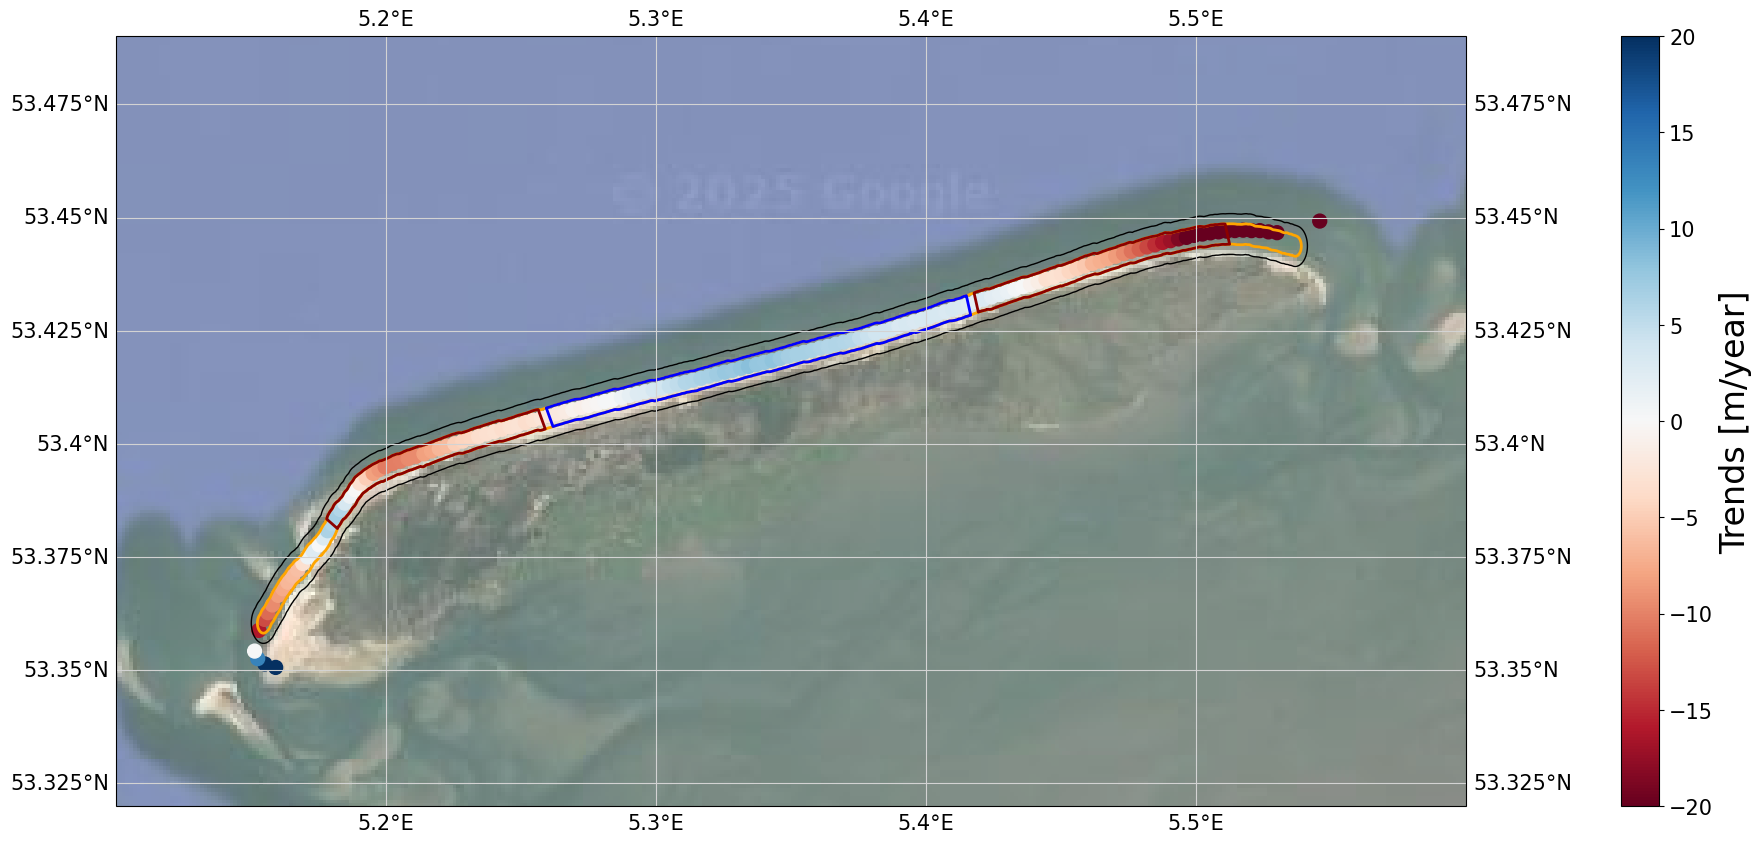

In [38]:
fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

trends = ax.scatter(lon_mean, lat_mean, marker='o', s=100, c=trend_jarkus['var_psmsl_uncorr'],
                  cmap='RdBu', vmin=-20, vmax=20, transform=ccrs.PlateCarree())

ax.add_geometries(poly_target, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black')
ax.add_geometries(poly_all, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='orange', linewidth=2)
ax.add_geometries(poly_west, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)
ax.add_geometries(poly_center, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)
ax.add_geometries(poly_east, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)

plt.colorbar(trends, shrink=1, pad=.08).set_label(label='Trends [m/year]',size=24)
ax.set_title('')

plt.savefig(f'{path_output}volume_areas_jarkus_trends.png', dpi=300, bbox_inches='tight')

## Time series of elevation changes

### Statistics compared to JARKUS

In [39]:
elev_stats = pd.DataFrame(index=jarkus_gdf.index)

for jarkus_point in jarkus_gdf.index:
    rts_ts = rts_interp.drop(columns='geometry').iloc[jarkus_point]
    idx, = np.where(np.isin(jarkus_gdf.columns, rts_ts.index)) # where jarkus years and rts years overlap
    jarkus_ts = jarkus_gdf.loc[jarkus_point].iloc[idx].astype(float)
    
    not_nan = np.logical_or(np.isnan(rts_ts), jarkus_ts.isna())
    # if number of nan values more than 50 % of the total number of values
    if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
        continue
        
    # RMSE
    elev_stats.loc[jarkus_point, 'rmse'] = CD_statistics.RMSE_timeseries(rts_ts, jarkus_ts)
    
    # # Correlation
    elev_stats.loc[jarkus_point, 'corr'], elev_stats.loc[jarkus_point, 'pvalue'] = stats.pearsonr(jarkus_ts[~not_nan], rts_ts[~not_nan])
    
    # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
    elev_trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
    elev_trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(jarkus_ts.index.values.astype(int), jarkus_ts.values)
    elev_stats.loc[jarkus_point, 'trend_diff'] = elev_trend_rts - elev_trend_jarkus


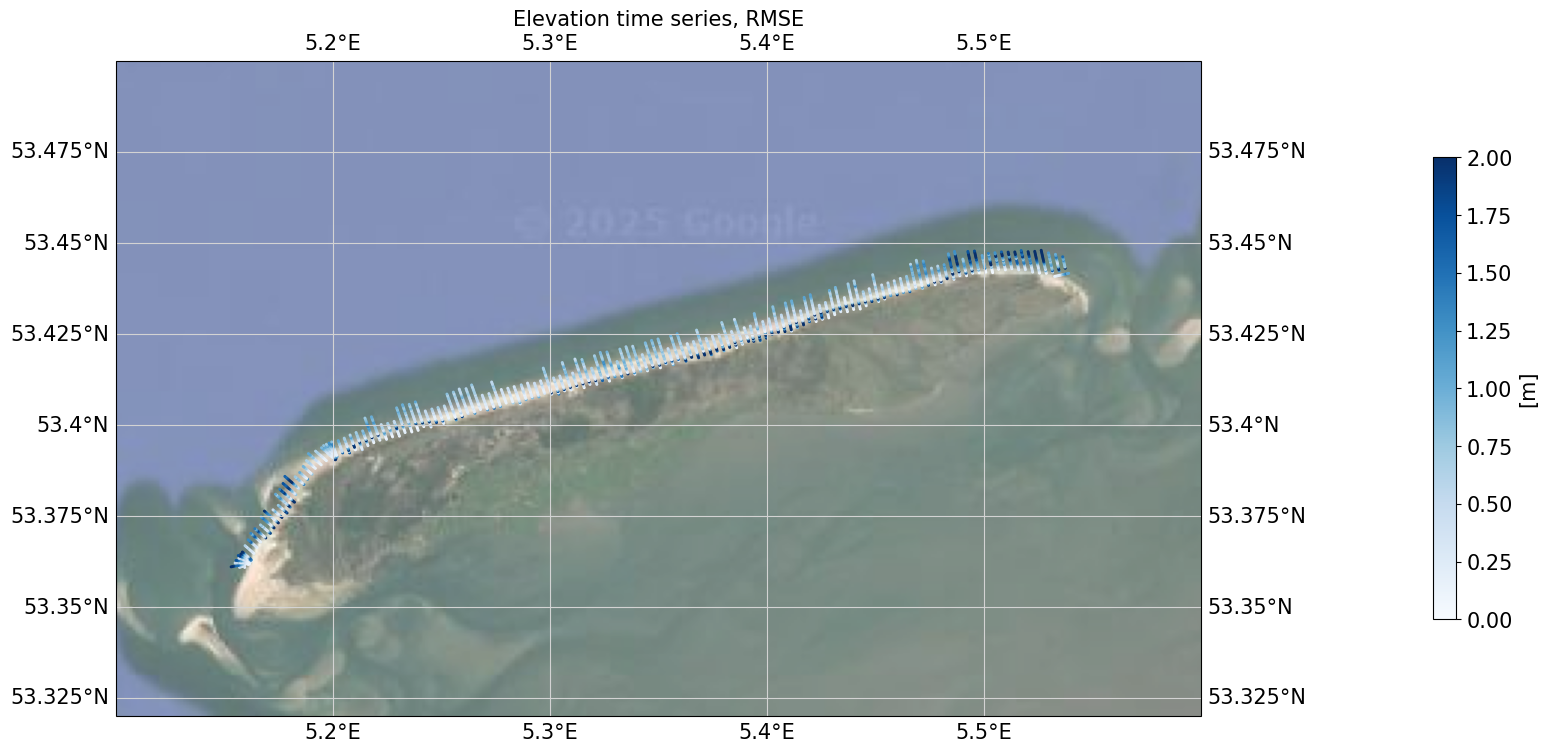

In [40]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['rmse'], vminmax=[0,2], cmap='Blues',
                          title='Elevation time series, RMSE', label='[m]')

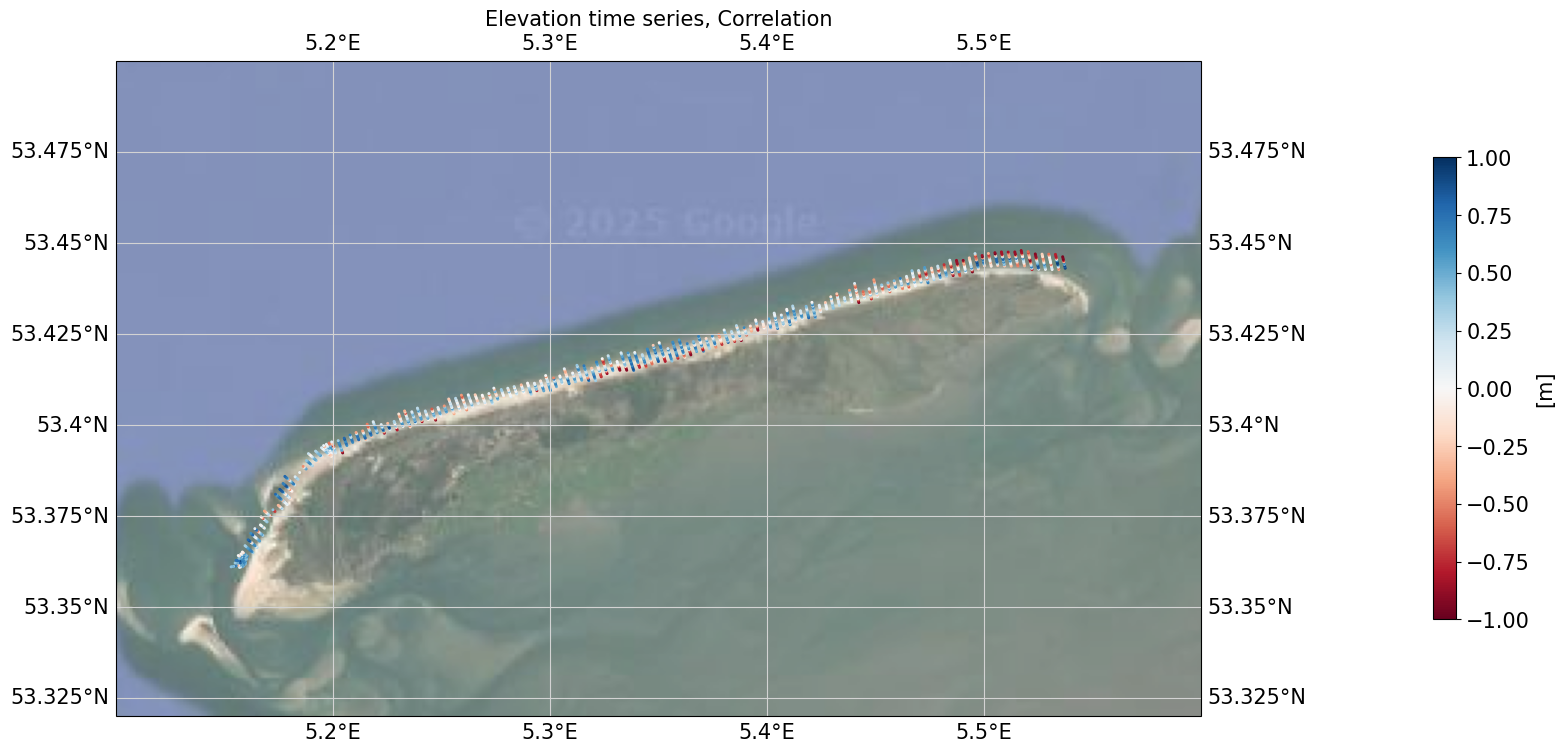

In [41]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['corr'], vminmax=[-1,1], cmap='RdBu',
                          title='Elevation time series, Correlation', label='[m]')

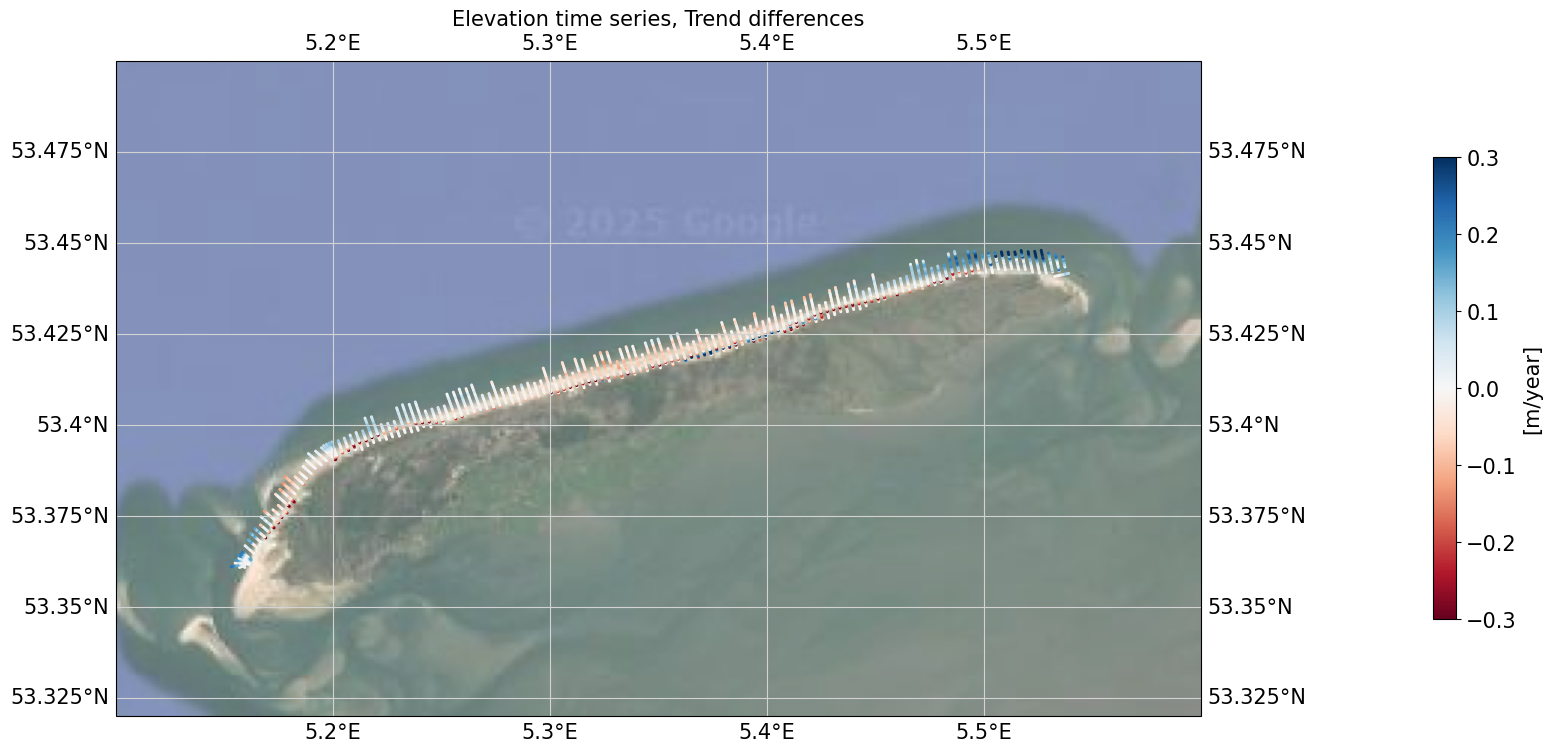

In [42]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['trend_diff'], vminmax=[-.3,.3], cmap='RdBu',
                          title='Elevation time series, Trend differences', label='[m/year]')

## Animation

#### KF

In [43]:
if animation:
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x = x_state.geometry.x
    y = x_state.geometry.y
    anim = CD_visualisation.movie(x_state, x, y,
            col_list_kf, first_col='init', savepath=path_output, fn='KF.gif')

#### RTS

In [44]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    anim_RTS = CD_visualisation.movie(x_state_s, x, y,
                col_list_s, first_col='x_s_2020', savepath=path_output, fn='RTS.gif')

#### Single year result map

In [45]:
x_state

,init,geometry,x_pred_1993,x_up_1993,x_pred_1994,x_up_1994,x_pred_1995,x_up_1995,x_pred_1996,x_up_1996,...,x_pred_2016,x_up_2016,x_pred_2017,x_up_2017,x_pred_2018,x_up_2018,x_pred_2019,x_up_2019,x_pred_2020,x_up_2020
0,NaN,POINT (5.15266 53.44803),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,POINT (5.15266 53.44713),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,POINT (5.15266 53.44623),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,POINT (5.15266 53.44533),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,POINT (5.15266 53.44443),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42233,NaN,POINT (5.53937 53.3644),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42234,NaN,POINT (5.53937 53.3635),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42235,NaN,POINT (5.53937 53.3626),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42236,NaN,POINT (5.53937 53.3617),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
x_state['x_up_2020']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
42233   NaN
42234   NaN
42235   NaN
42236   NaN
42237   NaN
Name: x_up_2020, Length: 42238, dtype: float64

Text(0.5, 1.0, '')

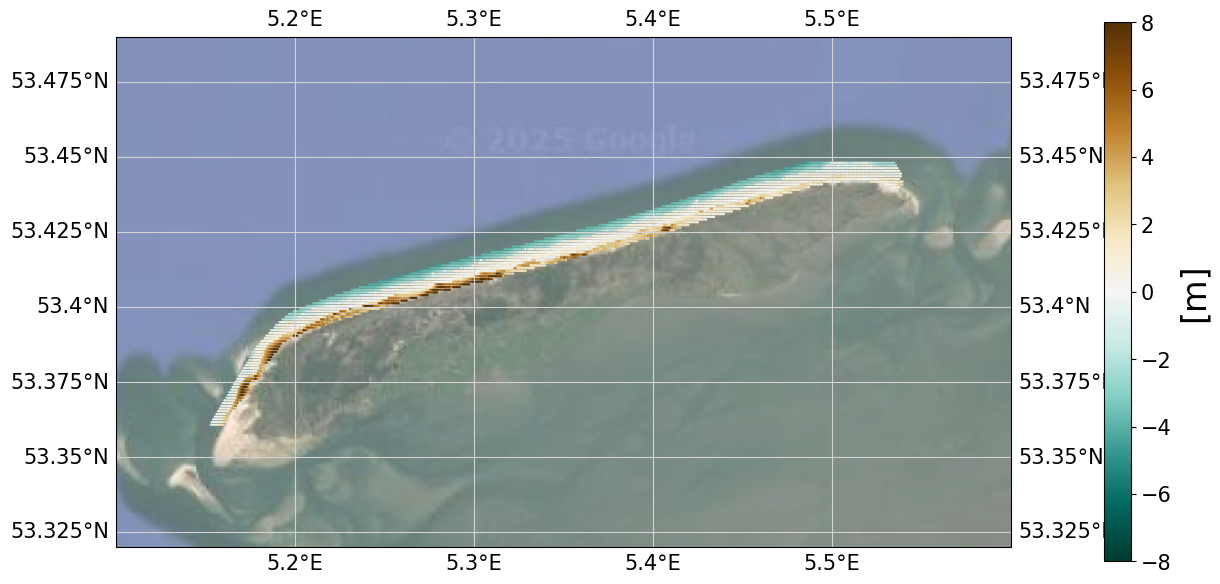

In [47]:
# %matplotlib qt5
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=.5, c=x_state['x_up_2020'],
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-8, vmax=8, )

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
ax.set_title('')

# plt.savefig(f'{path_output}volume_areas_jarkus_trends.png', dpi=300, bbox_inches='tight')